In [ ]:
!pip install keras_vggface
!pip install keras_applications
!pip install livelossplot

In [ ]:
import os
import time
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.models import load_model
from tensorflow.keras import Model
from tensorflow.keras.preprocessing import image
from keras_vggface.vggface import VGGFace
from keras_vggface import utils
from livelossplot.tf_keras import PlotLossesCallback
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter, ImageOps
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gdown

print('tensorflow -',tf.__version__)

tensorflow - 2.5.0


Подключение Google-диска

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Скачивание, распаковка zip-архивов с изображениями

In [ ]:
BASE_DIR = Path('/content')
PATH_MYDRIVE = Path('/content/drive/MyDrive/Skillbox/CNN_Final_Project/')
PATH_TRAIN = BASE_DIR / 'train'
PATH_TEST = BASE_DIR / 'test_kaggle'
PATH_PROCESSED = BASE_DIR / 'processed' # обрезанные по bounding-box изображения
os.chdir(BASE_DIR)

In [ ]:
from google_drive_downloader import GoogleDriveDownloader as gdd

# train.zip (предобработанные изображения по яркости/контрасту. см. Часть 1)
gdd.download_file_from_google_drive(file_id='1CRScUZYvmoKr6hnb82szdgRB7X-mEQjl',
                                    dest_path=BASE_DIR / 'train.zip', unzip=True)

#test_kaggle.zip (download from Kaggle)
gdd.download_file_from_google_drive(file_id='1bGHeWeWYXj5biL9s-qTc9gyv91WNAbWE',
                                    dest_path=BASE_DIR / 'test_kaggle.zip', unzip=True)

#processed.zip (обрезанные изображения по bounding_box. см. Часть 1)
gdd.download_file_from_google_drive(file_id='19opa0RXLduhHx8ziI7G15-cYZq_vws0f',
                                    dest_path=BASE_DIR / 'processed.zip', unzip=True)

#train.csv (download from Kaggle)
df = pd.read_csv(PATH_MYDRIVE / 'train.csv', sep=',', index_col=0)

Unzipping...Done.
Unzipping...Done.
Unzipping...Done.


In [ ]:
# датасеты. см. Часть 1
df_train = pd.read_csv(PATH_MYDRIVE / 'df_train.csv', sep=',', index_col='index')
df_processed = pd.read_csv(PATH_MYDRIVE / 'df_processed.csv', sep=',', index_col='index')
df_test = pd.read_csv(PATH_MYDRIVE / 'df_test.csv', sep=',', index_col='index')

------------------------------------

# Препроцессинг

### Разбиваем датасеты на обучающую и валидационную выборки

In [ ]:
# разделим датасет на обучающую и валидационную выборку
def stratified_split_ds(data, validation_split=0.2, seed=42):
    """Stratified split of dataframe base on column 'emotion'."""
    rnd_seed = np.random.RandomState(seed=seed)
    val_indices = []
    for category in data['emotion'].unique():
        sub_df = data[data['emotion'] == category]
        sub_val_len = int(sub_df.shape[0] * validation_split)
        cat_val_idx = rnd_seed.choice(sub_df.index, size=sub_val_len, replace=False)
        val_indices.extend(list(cat_val_idx))

    return data.drop(val_indices, axis=0), data.loc[val_indices,:]

df_train_v1, df_test_v1 = stratified_split_ds(df_train)
df_train_v1.to_csv(BASE_DIR / 'df_train_v1.csv', sep=',', index_label='index')
df_test_v1.to_csv(BASE_DIR / 'df_test_v1.csv', sep=',', index_label='index')
print('V1')
print(f'Train dataset size: {df_train_v1.shape[0]}')
print(f'Test dataset size: {df_test_v1.shape[0]}')
print('-------------------------')
print('V2')
df_train_v2, df_test_v2 = stratified_split_ds(df_processed)
df_train_v2.to_csv(BASE_DIR / 'df_train_v2.csv', sep=',', index_label='index')
df_test_v2.to_csv(BASE_DIR / 'df_test_v2.csv', sep=',', index_label='index')
print(f'Train dataset size: {df_train_v2.shape[0]}')
print(f'Test dataset size: {df_test_v2.shape[0]}')

V1
Train dataset size: 39215
Test dataset size: 9798
-------------------------
V2
Train dataset size: 39215
Test dataset size: 9798


In [ ]:
df_train_v1 = pd.read_csv(BASE_DIR/'df_train_v1.csv', sep=',', index_col='index')
df_train_v2 = pd.read_csv(BASE_DIR/'df_train_v2.csv', sep=',', index_col='index')
df_test_v1 = pd.read_csv(BASE_DIR/'df_test_v1.csv', sep=',', index_col='index')
df_test_v2 = pd.read_csv(BASE_DIR/'df_test_v2.csv', sep=',', index_col='index')

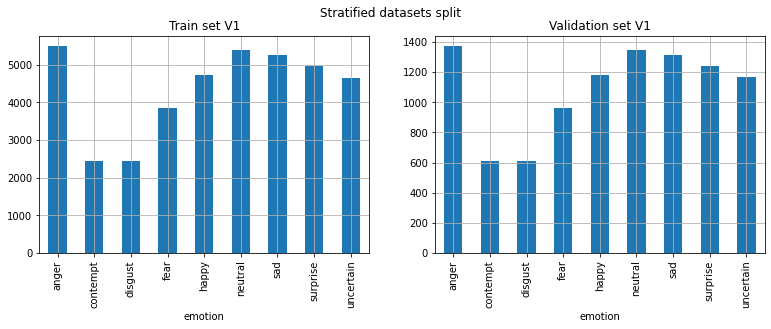

In [ ]:
plt.figure(figsize=(13,4))
plt.suptitle('Stratified datasets split')
plt.subplot(1, 2, 1)
df_train_v1.groupby('emotion')['image_path'].count().plot.bar()
plt.grid()
plt.title('Train set V1')
plt.subplot(1, 2, 2)
df_test_v1.groupby('emotion')['image_path'].count().plot.bar()
plt.title('Validation set V1')
plt.grid()
plt.show()

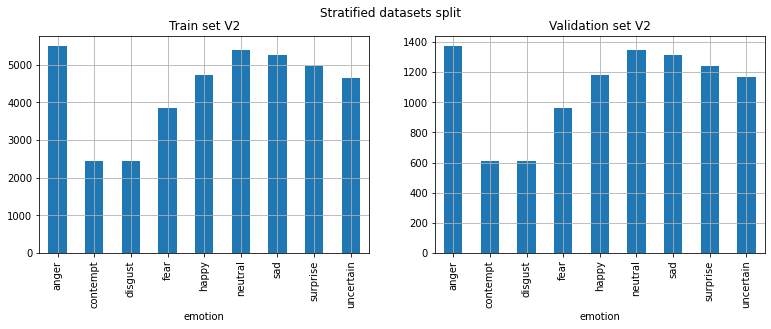

In [ ]:
plt.figure(figsize=(13,4))
plt.suptitle('Stratified datasets split')
plt.subplot(1, 2, 1)
df_train_v2.groupby('emotion')['filename'].count().plot.bar()
plt.grid()
plt.title('Train set V2')
plt.subplot(1, 2, 2)
df_test_v2.groupby('emotion')['filename'].count().plot.bar()
plt.title('Validation set V2')
plt.grid()
plt.show()

### Задаем различные фильтры для дополнительной аугментации

Измененяем насыщенность цветов, добавляем размытие или случайный шум (гаусовый, пуассона, соль-и-перец).

In [ ]:
def add_noise(noise_typ, img):
    """Add noise with numpy."""
    image = img / 255.
    if noise_typ == "gauss":
        row, col, ch= image.shape
        mean = 0
        var = 0.002
        sigma = var**0.5
        gauss = np.random.normal(mean, sigma, (row, col, ch))
        out = gauss + image
        out =  np.clip(out, 0, 1)
    elif noise_typ == "s&p":
        row, col, ch = image.shape
        s_vs_p = 0.5
        amount = 0.02
        out = np.copy(image)
        # Salt mode
        num_salt = np.ceil(amount * row * col * s_vs_p)
        coords = [np.random.randint(0, i - 1, int(num_salt))
              for i in image.shape[:2]]
        out[tuple(coords)] = np.random.uniform(0.6, 1.0)
        # Pepper mode
        num_pepper = np.ceil(amount* row * col * (1. - s_vs_p))
        coords = [np.random.randint(0, i - 1, int(num_pepper))
              for i in image.shape[:2]]
        out[tuple(coords)] = np.random.uniform(0, 0.4)
    elif noise_typ == "poisson":
        vals = len(np.unique(image))
        vals = 2 ** np.ceil(np.log2(vals))
        noisy = np.random.poisson(image * vals) / float(vals)
        out = np.clip(noisy, 0, 1)
    return (out * 255).astype(np.uint8)


def apply_filter(filter_type, img):
    """Apply blur or color filter."""
#     image = Image.fromarray(np.round(img * 255).astype(np.uint8))
    image = Image.fromarray(img)
    if filter_type == 'blur':
        out = image.filter(filter=ImageFilter.BLUR)
    elif filter_type == 'color':
        enhancer = ImageEnhance.Color(image)
        out = enhancer.enhance(np.random.uniform(0.4, 1.3))
    elif filter_type == 'gblur':
        out = image.filter(ImageFilter.GaussianBlur(1))
    return np.array(out)

def random_transformation(image):
    """
    Transform image with random filter or noise.
    Image assumed to be an array of shape (h, w, ch) 
    and color values are in [0, 255] range.
    Always varies colors saluration, and add noise/blur with 60% propability.
    """

    transformations = [
        lambda x: add_noise('gauss', x),
        lambda x: add_noise('s&p', x),
        lambda x: add_noise('poisson', x),
        lambda x: apply_filter('blur', x),
        lambda x: apply_filter('gblur', x),
        lambda x: x, # no filter
    ]
    p = [0.12, 0.12, 0.12, 0.12, 0.12, 0.40]

    trans_fn = np.random.choice(transformations, p=p)

    return apply_filter('color', trans_fn(image.astype(np.uint8))).astype(image.dtype)

def preprocess_input_facenet(image_):
    """
    image_ -- тензор размера (1, H, W, 3)
    
    return: картинка, с примененным preprocess_input(..., version=2) из keras_vggface
    """
    image_ = random_transformation(image_)
    preprocessed = utils.preprocess_input(image_, version=2)
    
    return preprocessed


def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip( images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Создадим вспомогательные функции для загрузки датасета и тестирования модели.

In [ ]:
def load_dataset(n, batch_size, image_size):
    """
    Create image generators for train and test data with specified parameters.
    """
    base_dir = BASE_DIR
    train_df = pd.read_csv(BASE_DIR/f'df_train_v{n}.csv', sep=',', index_col='index')
    test_df = pd.read_csv(BASE_DIR/f'df_test_v{n}.csv', sep=',', index_col='index')

    if n == 1:
        train_generator = ImageDataGenerator(
                                     rotation_range=15,
                                     width_shift_range=.05,
                                     height_shift_range=.05,
                                     horizontal_flip=True,
                                     fill_mode='nearest',
                                     brightness_range=(0.5,1.5),
                                     shear_range=0.2,
                                     zoom_range=.1,
                                     preprocessing_function=preprocess_input_facenet)
        
        train_data_gen = train_generator.flow_from_dataframe(dataframe=train_df,
                                                x_col='image_path',
                                                y_col='emotion',
                                                target_size=(image_size, image_size),
                                                batch_size=batch_size,
                                                class_mode='sparse',
                                                directory=str(PATH_TRAIN),
                                                shuffle=True,
                                                interpolation='nearest',
                                                validate_filenames=False
                                                )
        val_generator = ImageDataGenerator(preprocessing_function=preprocess_input_facenet)
        
        val_data_gen = val_generator.flow_from_dataframe(dataframe=test_df,
                                                         directory=str(PATH_TRAIN),
                                                         x_col='image_path',
                                                         y_col='emotion',
                                                         target_size=(image_size, image_size),
                                                         batch_size=batch_size,
                                                         class_mode='sparse',
                                                         shuffle=False,
                                                         interpolation='nearest',
                                                         validate_filenames=False
                                                        )
    elif n == 2:
        train_generator = ImageDataGenerator(
                                     rotation_range=2,
                                     width_shift_range=.05,
                                     height_shift_range=.05,
                                     horizontal_flip=True,
                                     fill_mode='nearest',
                                     brightness_range=(0.5,1.5),
                                     shear_range=0.1,
                                     zoom_range=.05,
                                     preprocessing_function=preprocess_input_facenet)
        
        train_data_gen = train_generator.flow_from_dataframe(dataframe=train_df,
                                                x_col='image_path',
                                                y_col='emotion',
                                                target_size=(image_size, image_size),
                                                batch_size=batch_size,
                                                class_mode='sparse',
                                                directory=str(PATH_PROCESSED),
                                                shuffle=True,
                                                interpolation='nearest',
                                                validate_filenames=False
                                                )
        val_generator = ImageDataGenerator(preprocessing_function=preprocess_input_facenet)
        
        val_data_gen = val_generator.flow_from_dataframe(dataframe=test_df,
                                                         directory=str(PATH_PROCESSED),
                                                         x_col='image_path',
                                                         y_col='emotion',
                                                         target_size=(image_size, image_size),
                                                         batch_size=batch_size,
                                                         class_mode='sparse',
                                                         shuffle=False,
                                                         interpolation='nearest',
                                                         validate_filenames=False
                                                        )
    else:
        raise ValueError('n should be integer and equal to 1 or 2.')
   
    assert train_data_gen.class_indices == val_data_gen.class_indices, "Class labels doesn't match between train and test sets."
    labels_dict = {v: k for k,v in train_data_gen.class_indices.items()}
    
    return train_data_gen, val_data_gen, labels_dict

def benchmark_model(model, sample, iterations=200):
    """Test inference time of the model."""
    model(sample) # warm-up inference
    inference_times = []
    for i in range(iterations):
        start = time.time()
        model(sample)
        inference_times.append(time.time() - start)
    mean_time = np.mean(inference_times)
    median_time = np.median(inference_times)
    plt.plot(inference_times)
    plt.title(f'Inference time over {iterations} iterations on one picture\n'
              f'mean time = {mean_time:.3f}sec, median time = {median_time:.3f}sec')
    plt.xlabel('Iteration number')
    plt.ylabel('Inference time, sec')
    plt.show()
    return mean_time, median_time

def deprocess_image(vggface_image):
    """
    vggface_image -- (H, W, 3) картинка после препросессинга. 
    содержит отрицательные значения и некорректно отображается matplotlib

    return: корректно отображаемая картинка типа np.uint8(!!). 

    ! работайте с копией картинки (image = np.copy(vggface_image)) !
    """
    image = np.copy(vggface_image)
    image[..., 0] += 91.4953
    image[..., 1] += 103.8827
    image[..., 2] += 131.0912
    image = image[..., ::-1]
    image = image.astype(np.uint8)
    
    return image

def show_examples(data_gen):
    x, y = next(data_gen)

    plt.figure(figsize=(15,15))
    plt.suptitle('Quick check of genereted images').set_y(0.92)
    for i in range(25):
        img = x[i]
        plt.subplot(5, 5, i + 1)
        plt.imshow(deprocess_image(img))
        plt.title(labels_dict[y[i]])
        plt.xticks([]); plt.yticks([])
    plt.show()

## Датасет №1

Загрузим фатафреймы для обучающей и валидационной выборок

In [ ]:
train_data_gen, val_data_gen, labels_dict = load_dataset(n=1, batch_size=128, image_size=224)
train_data_gen.class_indices

Found 39215 non-validated image filenames belonging to 9 classes.
Found 9798 non-validated image filenames belonging to 9 classes.


{'anger': 0,
 'contempt': 1,
 'disgust': 2,
 'fear': 3,
 'happy': 4,
 'neutral': 5,
 'sad': 6,
 'surprise': 7,
 'uncertain': 8}

Проверим качество аугментации

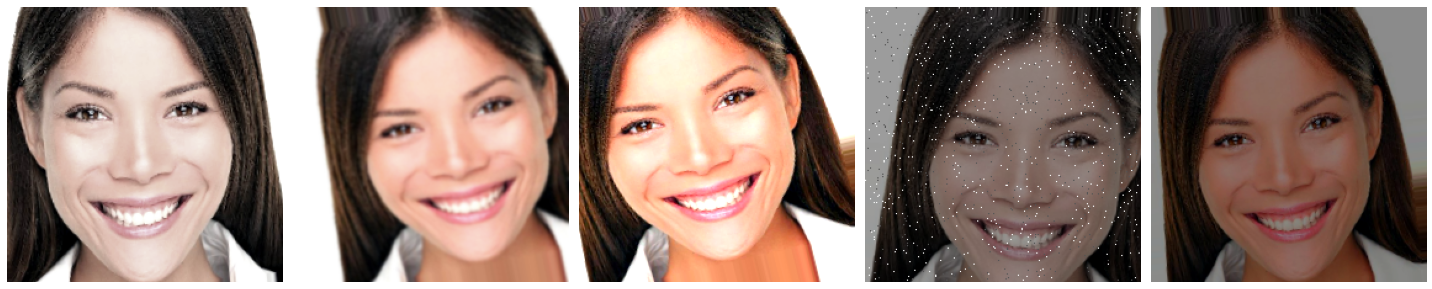

In [ ]:
augmented_images = [train_data_gen[0][0][0] for i in range(5)]
plotImages(deprocess_image(augmented_images))

Посмотрим выборочные изображения датасета_v1

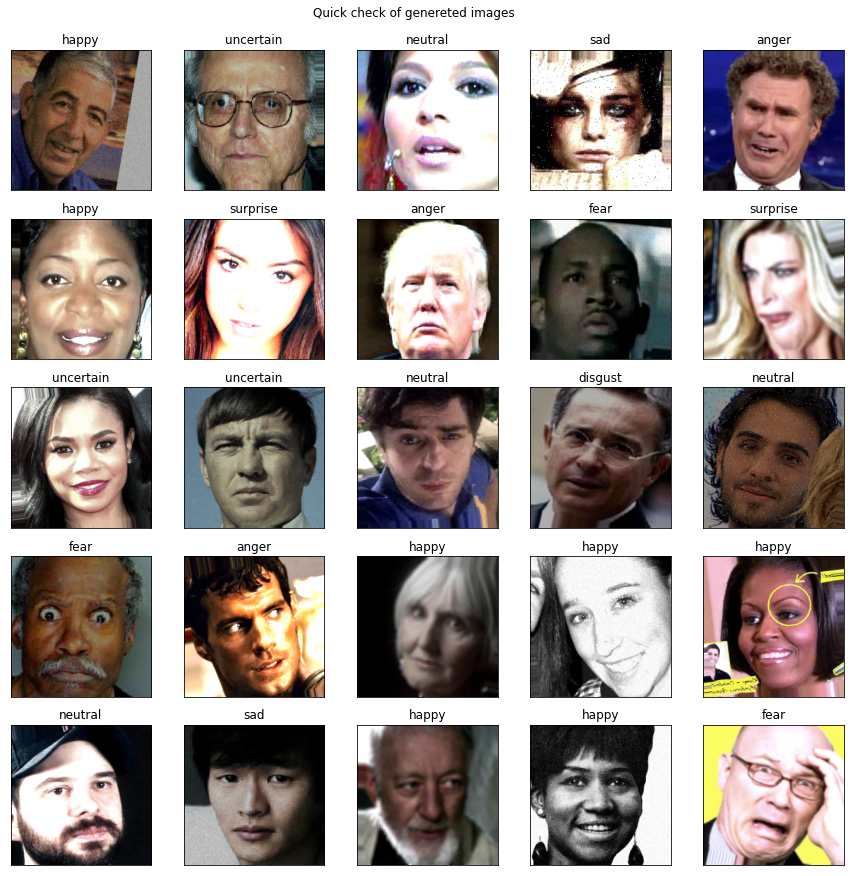

In [ ]:
show_examples(train_data_gen)

## Датасет №2

Посмотрим аугментацию...

In [ ]:
train_data_gen, val_data_gen, labels_dict = load_dataset(n=2, batch_size=128, image_size=224)

Found 39215 non-validated image filenames belonging to 9 classes.
Found 9798 non-validated image filenames belonging to 9 classes.


Found 39215 non-validated image filenames belonging to 9 classes.
Found 9798 non-validated image filenames belonging to 9 classes.


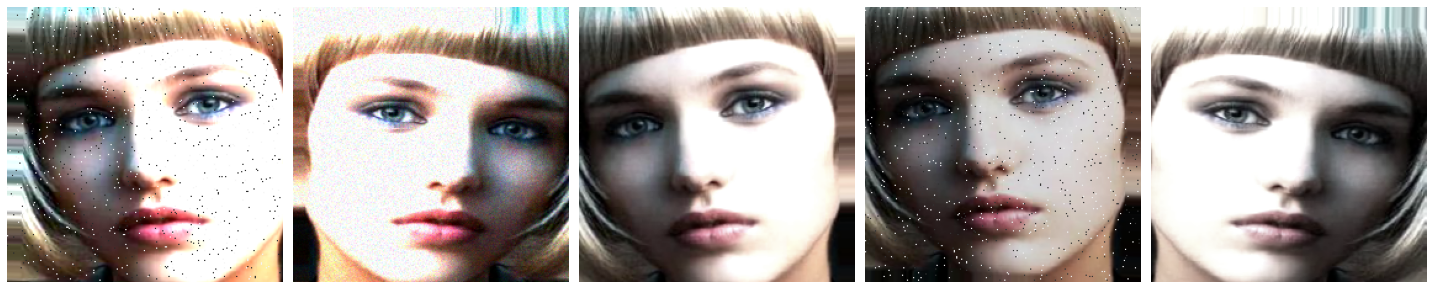

In [ ]:
augmented_images = [train_data_gen[0][0][0] for i in range(5)]
plotImages(deprocess_image(augmented_images))

И более расширенная выборка...

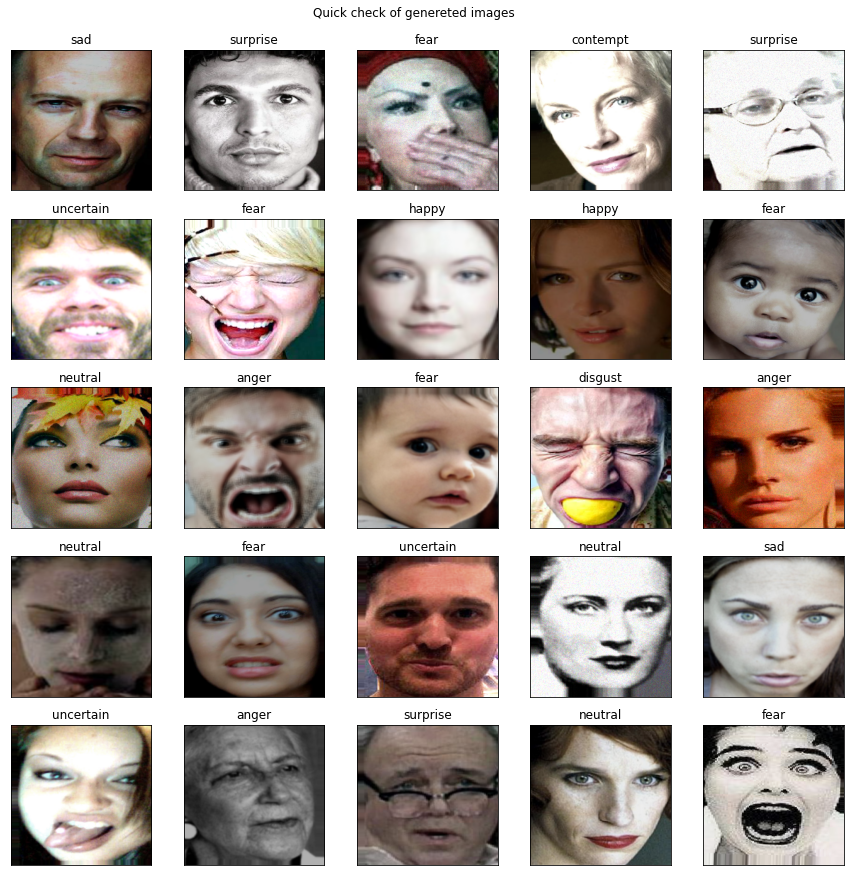

In [ ]:
show_examples(train_data_gen)

---

#Подбор модели и её обучение. Transfer learning and finetuning

---

Возьмем за основу сеть, которая была обучена на датасете [VGGFace2](http://www.robots.ox.ac.uk/~vgg/data/vgg_face2/) для классификации лиц. Она содержит 3.3 миллиона изображений с 9000 разными персоналиями. Сеть, которую будем дообучать, возьмем из открытого источника: https://github.com/rcmalli/keras-vggface .

"Отрежем" от vggface_model последние полносвязанные Dense-слои.
Последний слой базовой модели предсказывает для изображения 2048-мерный вектор признаков. Добавим Flatten-слой, преобразующий 3D-массив в 1D. Также добавим финальный полносвязанный слой с softmax-активацией по 9 классам.

In [ ]:
#Transfer learning and finetuning
vggface_model = VGGFace(model='resnet50', include_top=False, input_shape=(224, 224, 3))

model_emotion = tf.keras.Sequential([vggface_model, 
                                     tf.keras.layers.Flatten(), 
                                     tf.keras.layers.Dense(9, activation='softmax')])
model_emotion.build(input_shape=(None, 224, 224, 3))

model_emotion.summary()

94707712/94694792 [==============================] - 4s 0us/step
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
module_wrapper (ModuleWrappe (None, 1, 1, 2048)        23561152  
_________________________________________________________________
flatten (Flatten)            (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 9)                 18441     
Total params: 23,579,593
Trainable params: 23,526,473
Non-trainable params: 53,120
_________________________________________________________________


In [ ]:
# Словарь эмоций
emotion_mapping = dict(enumerate(df['emotion'].unique()))

### Обучение модели VGG по датасету №1

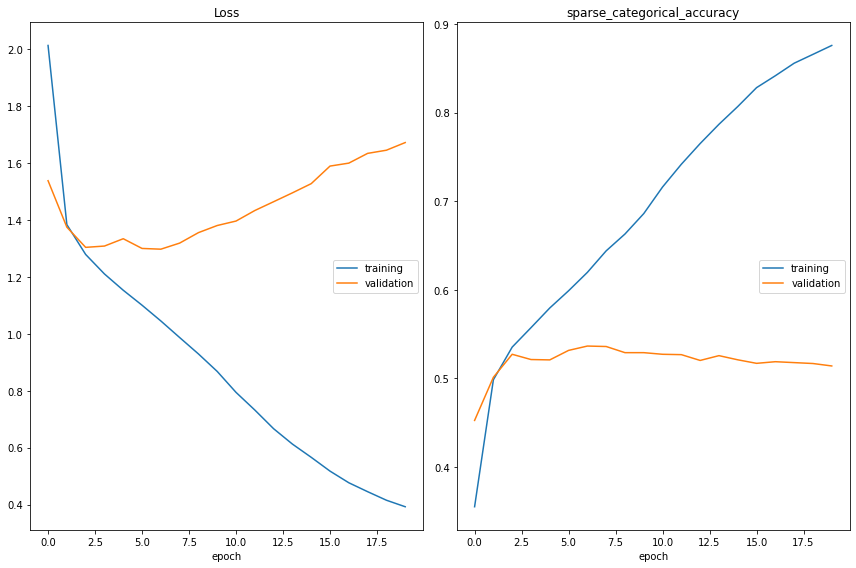

Loss
	training         	 (min:    0.392, max:    2.013, cur:    0.392)
	validation       	 (min:    1.297, max:    1.672, cur:    1.672)
sparse_categorical_accuracy
	training         	 (min:    0.355, max:    0.876, cur:    0.876)
	validation       	 (min:    0.453, max:    0.537, cur:    0.514)

Epoch 00020: val_sparse_categorical_accuracy did not improve from 0.53654


In [ ]:
cpt_path = str(PATH_MYDRIVE / 'model_emotion/checkpoint_best_vgg_weights.hdf5')
train_data_gen, val_data_gen, labels_dict = load_dataset(n=1, batch_size=128, image_size=224)

#LearningRateScheduler
def scheduler(epoch, lr):
   if epoch < 10:
     return lr
   else:
     return lr * tf.math.exp(-0.1)

my_callbacks = [PlotLossesCallback(),
                tf.keras.callbacks.ModelCheckpoint(cpt_path,
                                                   monitor='val_sparse_categorical_accuracy',
                                                   verbose=1,
                                                   save_best_only=True,
                                                   save_weights_only=True,
                                                   save_freq='epoch',
                                                   mode='max'),
                tf.keras.callbacks.LearningRateScheduler(scheduler)]  

model_emotion.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

EPOCHS = 20
history = model_emotion.fit(
    train_data_gen,
    epochs=EPOCHS,
    validation_data=val_data_gen,
    callbacks=my_callbacks)

Сохранение модели, загрузка лучших весов

In [ ]:
model_emotion.save(PATH_MYDRIVE / 'model_emotion/checkpoint_best_vgg')
model_emotion.load_weights(PATH_MYDRIVE / 'model_emotion/checkpoint_best_vgg_weights.hdf5')
loss, acc = model_emotion.evaluate(val_data_gen)

77/77 [==============================] - 171s 2s/step - loss: 1.2960 - sparse_categorical_accuracy: 0.5375


Выгрузка в Kaggle

In [ ]:
submission_data = []

for file in tqdm(df_test.image_path):
    img = image.load_img(PATH_TEST / file, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = utils.preprocess_input(x, version=2)
    predicts = model_emotion.predict(x)
    emotion = emotion_mapping[np.argmax(predicts)]
    submission_data.append((file, emotion))
    
sample_submission = pd.DataFrame()
sample_submission['image_path'], sample_submission['emotion'] = zip(*submission_data)

100%|██████████| 5000/5000 [04:01<00:00, 20.72it/s]


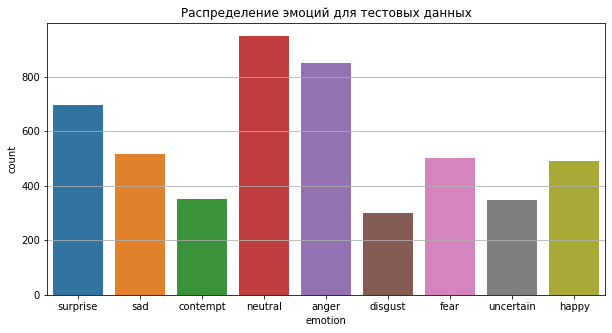

In [ ]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = sample_submission, x='emotion', ax=ax).set_title('Распределение эмоций для тестовых данных')
plt.grid(axis='y')
plt.show()

In [ ]:
sample_submission.to_csv(PATH_MYDRIVE / 'model_emotion/sample_submission.csv', index=False)

Тестируем время инференса сети

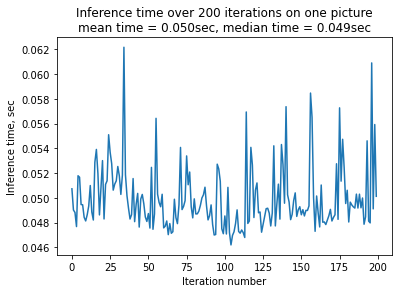

(0.0499079430103302, 0.04918384552001953)

In [ ]:
x, y = next(train_data_gen)
sample = x[0:1]
benchmark_model(model_emotion, sample)

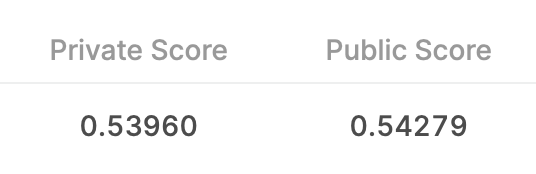

### Обучение модели VGG по датасету №2 (обрезанные по bounding_box изображения)

In [ ]:
vggface_model = VGGFace(model='resnet50', include_top=False, input_shape=(224, 224, 3))
model_emotion = tf.keras.Sequential([vggface_model, 
                                     tf.keras.layers.Flatten(), 
                                     tf.keras.layers.Dense(9, activation='softmax')])
model_emotion.build(input_shape=(None, 224, 224, 3))

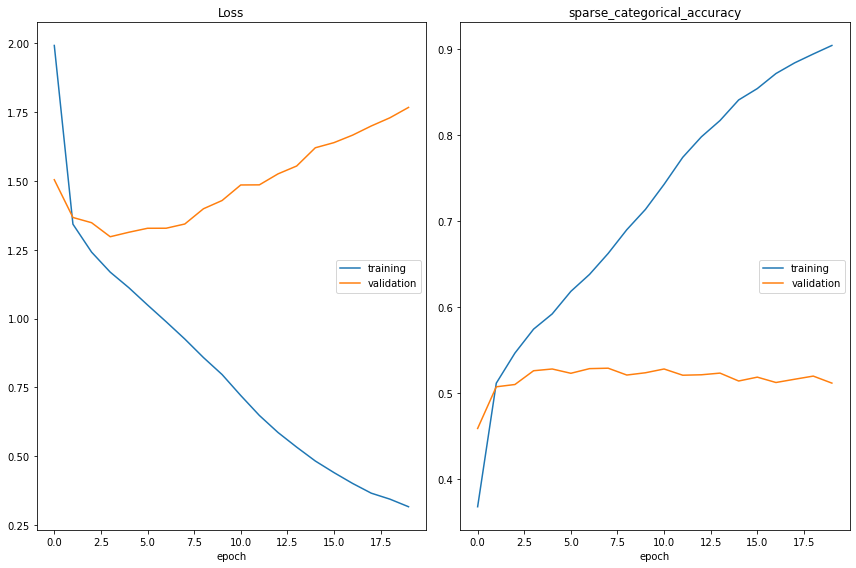

Loss
	training         	 (min:    0.317, max:    1.992, cur:    0.317)
	validation       	 (min:    1.297, max:    1.767, cur:    1.767)
sparse_categorical_accuracy
	training         	 (min:    0.368, max:    0.904, cur:    0.904)
	validation       	 (min:    0.459, max:    0.529, cur:    0.511)

Epoch 00020: val_sparse_categorical_accuracy did not improve from 0.52878


In [ ]:
cpt_path = str(PATH_MYDRIVE / 'model_emotion/checkpoint_best_vgg_bb_weights.hdf5')

train_data_gen, val_data_gen, labels_dict = load_dataset(n=2, batch_size=128, image_size=224)

#LearningRateScheduler
def scheduler(epoch, lr):
   if epoch < 10:
     return lr
   else:
     return lr * tf.math.exp(-0.1)

my_callbacks = [PlotLossesCallback(),
                tf.keras.callbacks.ModelCheckpoint(cpt_path,
                                                   monitor='val_sparse_categorical_accuracy',
                                                   verbose=1,
                                                   save_best_only=True,
                                                   save_weights_only=True,
                                                   save_freq='epoch',
                                                   mode='max'),
                tf.keras.callbacks.LearningRateScheduler(scheduler)]  

model_emotion.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

EPOCHS = 20
history = model_emotion.fit(
    train_data_gen,
    epochs=EPOCHS,
    validation_data=val_data_gen,
    callbacks=my_callbacks)

Сохранение модели, загрузка лучших весов

In [ ]:
model_emotion.save(PATH_MYDRIVE / 'model_emotion/checkpoint_best_vgg_bb')
model_emotion.load_weights(PATH_MYDRIVE / 'model_emotion/checkpoint_best_vgg_bb_weights.hdf5')
loss, acc = model_emotion.evaluate(val_data_gen)

77/77 [==============================] - 112s 1s/step - loss: 1.3448 - sparse_categorical_accuracy: 0.5290


Выгрузка в Kaggle

In [ ]:
submission_data = []

for file in tqdm(df_test.image_path):
    img = image.load_img(PATH_TEST / file, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = utils.preprocess_input(x, version=2)
    predicts = model_emotion.predict(x)
    emotion = emotion_mapping[np.argmax(predicts)]
    submission_data.append((file, emotion))
    
sample_submission = pd.DataFrame()
sample_submission['image_path'], sample_submission['emotion'] = zip(*submission_data)

100%|██████████| 5000/5000 [04:09<00:00, 20.06it/s]


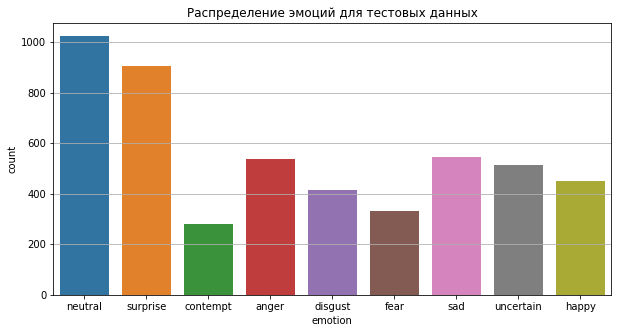

In [ ]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = sample_submission, x='emotion', ax=ax).set_title('Распределение эмоций для тестовых данных')
plt.grid(axis='y')
plt.show()

In [ ]:
sample_submission.to_csv(PATH_MYDRIVE / 'model_emotion/sample_submission_bb.csv', index=False)

Тестируем время инференса сети

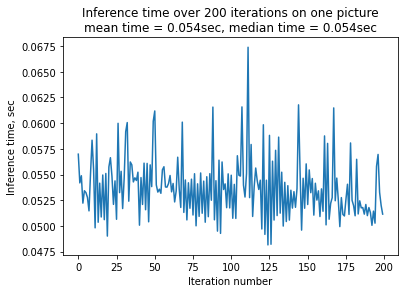

(0.053729586601257324, 0.053560853004455566)

In [ ]:
x, y = next(train_data_gen)
sample = x[0:1]
benchmark_model(model_emotion, sample)

## 2. BiT model with BiT HyperRule fine-tuning ([link](https://blog.tensorflow.org/2020/05/bigtransfer-bit-state-of-art-transfer-learning-computer-vision.html)).

Следующим вариантом обучим BiT (Big Transfer) сеть, которая создавалась для дообучения под различные задачи. В качастве основы возьмем BiT-M r50x1 модель (архитектура ResNet-50, веса обученны на ImageNet-21k (также известный как "полный ImageNet, релиз осени 2011"). Отличием BiT модели от ResNet является применение стандартизации ядра сверточных слоев, т.е. свертка применяется с ядром (kernel-mean)/var вместо kernel, а так же использованием GroupNormalization (GN) вместо BatchNormalization (BN) при распределенном обучении на ImageNet-21k.

In [ ]:
def load_BiT_dataset(batch_size, image_size):
    """
    Create image generators for train and test data with specified parameters.
    """
    train_df = pd.read_csv(BASE_DIR/f'df_train_v1.csv', sep=',', index_col='index')
    test_df = pd.read_csv(BASE_DIR/f'df_test_v1.csv', sep=',', index_col='index')

    train_generator = ImageDataGenerator(rescale=1./255,
                                     rotation_range=15,
                                     width_shift_range=.05,
                                     height_shift_range=.05,
                                     horizontal_flip=True,
                                     fill_mode='nearest',
                                     brightness_range=(0.5,1.5),
                                     shear_range=0.2,
                                     zoom_range=.1,
                                     preprocessing_function=random_transformation)
        
    train_data_gen = train_generator.flow_from_dataframe(dataframe=train_df,
                                                x_col='image_path',
                                                y_col='emotion',
                                                target_size=(image_size, image_size),
                                                batch_size=batch_size,
                                                class_mode='sparse',
                                                directory=str(PATH_TRAIN),
                                                shuffle=True,
                                                interpolation='nearest',
                                                validate_filenames=False
                                                )
    val_generator = ImageDataGenerator(rescale=1./255)
        
    val_data_gen = val_generator.flow_from_dataframe(dataframe=test_df,
                                                         directory=str(PATH_TRAIN),
                                                         x_col='image_path',
                                                         y_col='emotion',
                                                         target_size=(image_size, image_size),
                                                         batch_size=batch_size,
                                                         class_mode='sparse',
                                                         shuffle=False,
                                                         interpolation='nearest',
                                                         validate_filenames=False
                                                        )
    
    return train_data_gen, val_data_gen

In [ ]:
train_data_gen, val_data_gen  = load_BiT_dataset(batch_size=64, image_size=224)

Found 39215 non-validated image filenames belonging to 9 classes.
Found 9798 non-validated image filenames belonging to 9 classes.


In [ ]:
N_CLASSES = len(train_data_gen.class_indices)
BATCH_SIZE = 64
IMG_SIZE = 224

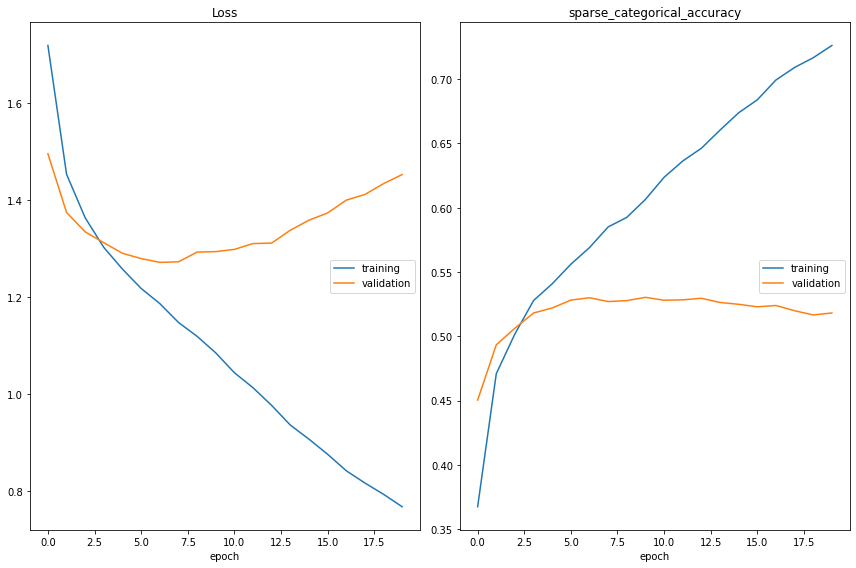

Loss
	training         	 (min:    0.768, max:    1.719, cur:    0.768)
	validation       	 (min:    1.272, max:    1.496, cur:    1.453)
sparse_categorical_accuracy
	training         	 (min:    0.367, max:    0.726, cur:    0.726)
	validation       	 (min:    0.450, max:    0.530, cur:    0.518)

Epoch 00020: val_sparse_categorical_accuracy did not improve from 0.53031
INFO:tensorflow:Assets written to: /content/drive/MyDrive/Skillbox/CNN_Final_Project/model_emotion/checkpoint_best_BiT/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/Skillbox/CNN_Final_Project/model_emotion/checkpoint_best_BiT/assets


154/154 [==============================] - 72s 466ms/step - loss: 1.2939 - sparse_categorical_accuracy: 0.5303


100%|██████████| 5000/5000 [04:54<00:00, 16.99it/s]


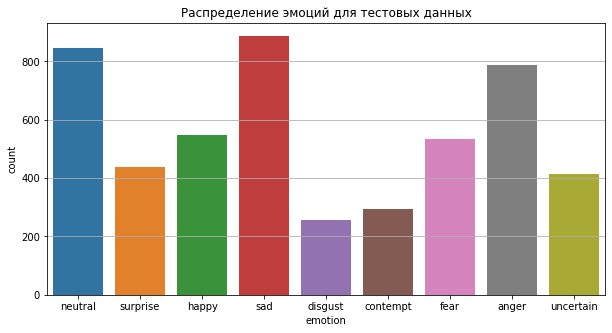

In [ ]:
cpt_path = str(PATH_MYDRIVE / 'model_emotion/checkpoint_best_BiT_weigts.hdf5')

#LearningRateScheduler
def scheduler(epoch, lr):
   if epoch < 10:
     return lr
   else:
     return lr * tf.math.exp(-0.1)
     
# BiT HyperRule
model_emotion = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3), name='input'),
            hub.KerasLayer("https://tfhub.dev/google/bit/m-r50x1/1", trainable=True),
            tf.keras.layers.Dense(N_CLASSES, activation='softmax', name='output', kernel_initializer='zeros')
        ])

my_callbacks = [PlotLossesCallback(),
                tf.keras.callbacks.ModelCheckpoint(cpt_path,
                                                   monitor='val_sparse_categorical_accuracy',
                                                   verbose=1,
                                                   save_best_only=True,
                                                   save_weights_only=True,
                                                   save_freq='epoch',
                                                   mode='max'),
                tf.keras.callbacks.LearningRateScheduler(scheduler)]  

model_emotion.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

EPOCHS = 20
history = model_emotion.fit(
    train_data_gen,
    epochs=EPOCHS,
    validation_data=val_data_gen,
    callbacks=my_callbacks)

model_emotion.save(PATH_MYDRIVE / 'model_emotion/checkpoint_best_BiT')
model_emotion.load_weights(PATH_MYDRIVE / 'model_emotion/checkpoint_best_BiT_weigts.hdf5')
loss, acc = model_emotion.evaluate(val_data_gen)

submission_data = []
for file in tqdm(df_test.image_path):
    img = image.load_img(PATH_TEST / file, target_size=(224, 224))
    x = image.img_to_array(img)
    x = x / 255.
    x = np.expand_dims(x, axis=0)
    predicts = model_emotion.predict(x)
    emotion = emotion_mapping[np.argmax(predicts)]
    submission_data.append((file, emotion))
    
sample_submission = pd.DataFrame()
sample_submission['image_path'], sample_submission['emotion'] = zip(*submission_data)

fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = sample_submission, x='emotion', ax=ax).set_title('Распределение эмоций для тестовых данных')
plt.grid(axis='y')
plt.show()

sample_submission.to_csv(PATH_MYDRIVE / 'model_emotion/sample_submission_BiT.csv', index=False)

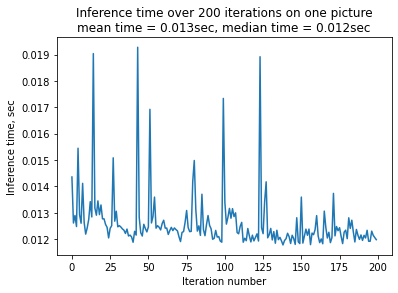

(0.012600393295288085, 0.012336015701293945)

In [ ]:
x, y = next(train_data_gen)
sample = x[0:1]
benchmark_model(model_emotion, sample)

### BiT model по обрезанным изображениям (bounding_box)

In [ ]:
def load_BiT_bb_dataset(batch_size, image_size):
    """
    Create image generators for train and test data with specified parameters.
    """
    train_df = pd.read_csv(BASE_DIR/f'df_train_v1.csv', sep=',', index_col='index')
    test_df = pd.read_csv(BASE_DIR/f'df_test_v1.csv', sep=',', index_col='index')

    train_generator = ImageDataGenerator(rescale=1./255,
                                     rotation_range=15,
                                     width_shift_range=.05,
                                     height_shift_range=.05,
                                     horizontal_flip=True,
                                     fill_mode='nearest',
                                     brightness_range=(0.5,1.5),
                                     shear_range=0.2,
                                     zoom_range=.1,
                                     preprocessing_function=random_transformation)
        
    train_data_gen = train_generator.flow_from_dataframe(dataframe=train_df,
                                                x_col='image_path',
                                                y_col='emotion',
                                                target_size=(image_size, image_size),
                                                batch_size=batch_size,
                                                class_mode='sparse',
                                                directory=str(PATH_PROCESSED),
                                                shuffle=True,
                                                interpolation='nearest',
                                                validate_filenames=False
                                                )
    val_generator = ImageDataGenerator(rescale=1./255)
        
    val_data_gen = val_generator.flow_from_dataframe(dataframe=test_df,
                                                         directory=str(PATH_PROCESSED),
                                                         x_col='image_path',
                                                         y_col='emotion',
                                                         target_size=(image_size, image_size),
                                                         batch_size=batch_size,
                                                         class_mode='sparse',
                                                         shuffle=False,
                                                         interpolation='nearest',
                                                         validate_filenames=False
                                                        )
    
    return train_data_gen, val_data_gen

In [ ]:
train_data_gen, val_data_gen  = load_BiT_bb_dataset(batch_size=64, image_size=224)

Found 39215 non-validated image filenames belonging to 9 classes.
Found 9798 non-validated image filenames belonging to 9 classes.


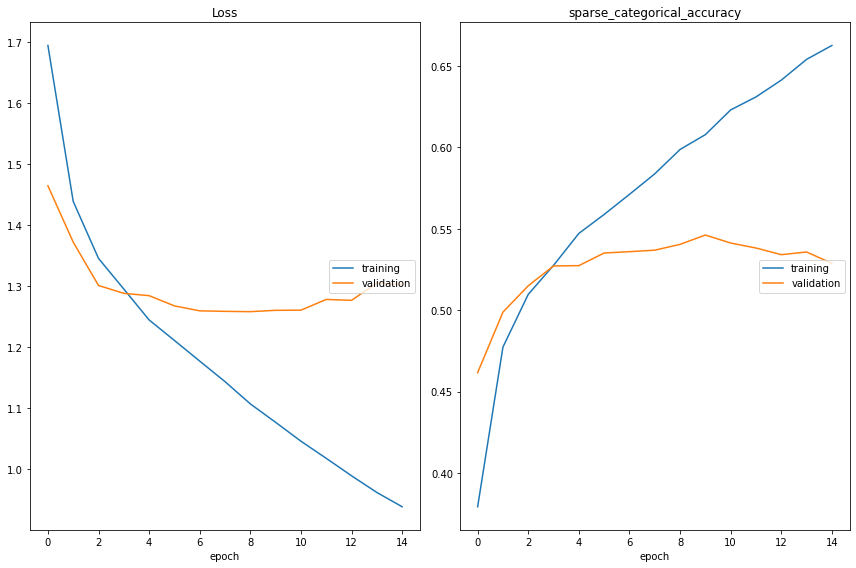

Loss
	training         	 (min:    0.939, max:    1.694, cur:    0.939)
	validation       	 (min:    1.258, max:    1.464, cur:    1.302)
sparse_categorical_accuracy
	training         	 (min:    0.379, max:    0.663, cur:    0.663)
	validation       	 (min:    0.462, max:    0.546, cur:    0.529)

Epoch 00015: val_sparse_categorical_accuracy did not improve from 0.54613
INFO:tensorflow:Assets written to: /content/drive/MyDrive/Skillbox/CNN_Final_Project/model_emotion/checkpoint_best_BiT_bb/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/Skillbox/CNN_Final_Project/model_emotion/checkpoint_best_BiT_bb/assets


154/154 [==============================] - 50s 325ms/step - loss: 1.2604 - sparse_categorical_accuracy: 0.5461


100%|██████████| 5000/5000 [04:45<00:00, 17.48it/s]


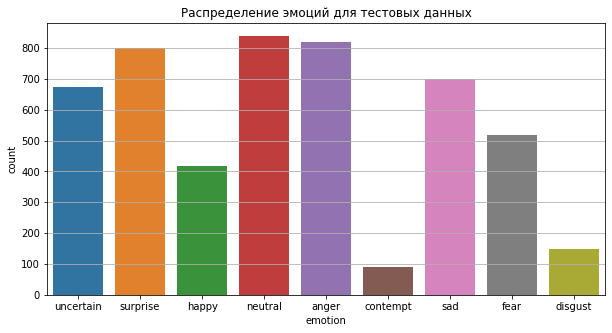

In [ ]:
cpt_path = str(PATH_MYDRIVE / 'model_emotion/checkpoint_best_BiT_bb_weigts.hdf5')

#LearningRateScheduler
def scheduler(epoch, lr):
   if epoch < 7:
     return lr
   else:
     return lr * tf.math.exp(-0.1)
     
# BiT HyperRule
model_emotion = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3), name='input'),
            hub.KerasLayer("https://tfhub.dev/google/bit/m-r50x1/1", trainable=True),
            tf.keras.layers.Dense(N_CLASSES, activation='softmax', name='output', kernel_initializer='zeros')
        ])

my_callbacks = [PlotLossesCallback(),
                tf.keras.callbacks.ModelCheckpoint(cpt_path,
                                                   monitor='val_sparse_categorical_accuracy',
                                                   verbose=1,
                                                   save_best_only=True,
                                                   save_weights_only=True,
                                                   save_freq='epoch',
                                                   mode='max'),
                tf.keras.callbacks.LearningRateScheduler(scheduler)]  

model_emotion.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

EPOCHS = 15
history = model_emotion.fit(
    train_data_gen,
    epochs=EPOCHS,
    validation_data=val_data_gen,
    callbacks=my_callbacks)

model_emotion.save(PATH_MYDRIVE / 'model_emotion/checkpoint_best_BiT_bb')
model_emotion.load_weights(PATH_MYDRIVE / 'model_emotion/checkpoint_best_BiT_bb_weigts.hdf5')
loss, acc = model_emotion.evaluate(val_data_gen)

submission_data = []
for file in tqdm(df_test.image_path):
    img = image.load_img(PATH_TEST / file, target_size=(224, 224))
    x = image.img_to_array(img)
    x = x / 255.
    x = np.expand_dims(x, axis=0)
    predicts = model_emotion.predict(x)
    emotion = emotion_mapping[np.argmax(predicts)]
    submission_data.append((file, emotion))
    
sample_submission = pd.DataFrame()
sample_submission['image_path'], sample_submission['emotion'] = zip(*submission_data)

fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = sample_submission, x='emotion', ax=ax).set_title('Распределение эмоций для тестовых данных')
plt.grid(axis='y')
plt.show()

sample_submission.to_csv(PATH_MYDRIVE / 'model_emotion/sample_submission_BiT_bb.csv', index=False)

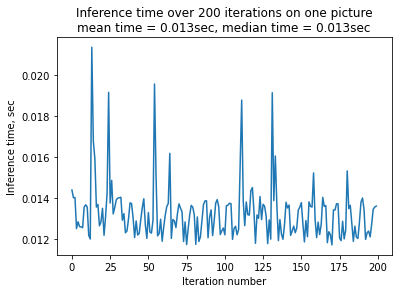

(0.013267226219177246, 0.013059377670288086)

In [ ]:
x, y = next(train_data_gen)
sample = x[0:1]
benchmark_model(model_emotion, sample)

---

# Балансировка датасета на базе VGGFace с максимальным Private Score
Идея балансировки заключается в наполнении дополнительными изображениями тех категорий, в которых количество файлов меньше, чем в самой многочисленной категории (anger). При этом дополнительные изображения получаем из тех, чей предикт соответствует той эмоции, в которой данные файлы расположены (заведомо "верные"), с последующей их АУГМЕНТАЦИЕЙ.

In [ ]:
vggface_model = VGGFace(model='resnet50', include_top=False, input_shape=(224, 224, 3))

model_emotion = tf.keras.Sequential([vggface_model, 
                                     tf.keras.layers.Flatten(), 
                                     tf.keras.layers.Dense(9, activation='softmax')])
model_emotion.build(input_shape=(None, 224, 224, 3))

model_emotion.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

model_emotion.load_weights(PATH_MYDRIVE / 'model_emotion/checkpoint_best_vgg_weights.hdf5')

train_data_gen, val_data_gen, labels_dict = load_dataset(n=1, batch_size=128, image_size=224)
loss, acc = model_emotion.evaluate(val_data_gen)

94707712/94694792 [==============================] - 4s 0us/step
Found 39215 non-validated image filenames belonging to 9 classes.
Found 9798 non-validated image filenames belonging to 9 classes.
77/77 [==============================] - 155s 2s/step - loss: 1.2963 - sparse_categorical_accuracy: 0.5380


1956 неверно распознанных фото из neutral - 29 % : {'anger': 519, 'surprise': 345, 'contempt': 341, 'sad': 270, 'uncertain': 211, 'fear': 147, 'disgust': 68, 'happy': 55}
1555 неверно распознанных фото из anger - 23 % : {'neutral': 574, 'disgust': 247, 'fear': 187, 'surprise': 154, 'sad': 148, 'uncertain': 133, 'contempt': 92, 'happy': 20}
1369 неверно распознанных фото из fear - 28 % : {'surprise': 549, 'anger': 250, 'sad': 202, 'neutral': 153, 'disgust': 117, 'uncertain': 55, 'happy': 29, 'contempt': 14}
2640 неверно распознанных фото из sad - 40 % : {'neutral': 1112, 'anger': 592, 'fear': 356, 'surprise': 199, 'disgust': 161, 'uncertain': 151, 'contempt': 50, 'happy': 19}
1240 неверно распознанных фото из disgust - 41 % : {'anger': 553, 'neutral': 152, 'uncertain': 130, 'sad': 123, 'fear': 110, 'surprise': 74, 'happy': 57, 'contempt': 41}
1947 неверно распознанных фото из surprise - 31 % : {'fear': 700, 'neutral': 466, 'uncertain': 233, 'anger': 186, 'happy': 164, 'sad': 82, 'contem

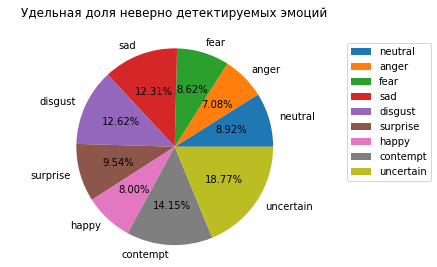

In [ ]:
from collections import Counter
df_train_exp = df_train.copy()
count = 0
emotion_list = []
values = []
labels = []
max_em_len = df_train.groupby(['emotion']).agg({'filename':'count'})['filename'].max()

for emotions in set(df_train['emotion'].tolist()):
    current_em_len = df_train[df_train['emotion']==emotions].shape[0]
    
    for row in df_train[df_train['emotion']==emotions].iterrows():
        img = image.load_img(PATH_TRAIN / str(row[1][8]), target_size=(224, 224))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = utils.preprocess_input(x, version=2)
        predicts = model_emotion.predict(x)
        emotion = emotion_mapping[np.argmax(predicts)]
        if emotion != emotions:
            emotion_list.append(emotion)
            count += 1
        elif emotion == emotions and current_em_len < max_em_len:
            current_em_len += 1
            img = np.array(img)
            img = random_transformation(img)
            img = Image.fromarray(img)
            img.save(PATH_TRAIN / emotions / (str(current_em_len + 1000) + str('.jpg')))
            new_row = {'emotion':emotions, 'filename':str(current_em_len + 1000)+ '.jpg', 'image_path':emotions + str('/') + str(current_em_len + 1000)+ '.jpg'}
            df_train_exp = df_train_exp.append(new_row, ignore_index=True)
    print(count,'неверно распознанных фото из', emotions,'-',round(count/len(df_train[df_train['emotion']==emotions].index)*100), 
          '% :', dict(sorted(Counter(emotion_list).items(), key=lambda x: x[1], reverse=True)))
    values.append(round(count/len(df_train[df_train['emotion']==emotions].index)*100))
    labels.append(emotions)
    count = 0
    emotion_list = []
    
fig1, ax1 = plt.subplots()
 
wedges, texts, autotexts = ax1.pie(values, labels=labels, autopct='%1.2f%%')
ax1.axis('equal')
ax1.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.title('Удельная доля неверно детектируемых эмоций\n')
plt.show()

df_train_exp.to_csv(PATH_MYDRIVE / 'df_train_exp.csv', sep=',', index_label='index')

# Переобучение модели VGGFace по сбалансированному дата-сету

In [ ]:
df_train_exp = pd.read_csv(PATH_MYDRIVE / 'df_train_exp.csv', sep=',', index_col='index')
df_train_v1, df_test_v1 = stratified_split_ds(df_train_exp)
df_train_v1.to_csv(BASE_DIR / 'df_train_v1.csv', sep=',', index_label='index')
df_test_v1.to_csv(BASE_DIR / 'df_test_v1.csv', sep=',', index_label='index')
print(f'Train dataset size: {df_train_v1.shape[0]}')
print(f'Test dataset size: {df_test_v1.shape[0]}')

Train dataset size: 46104
Test dataset size: 11521


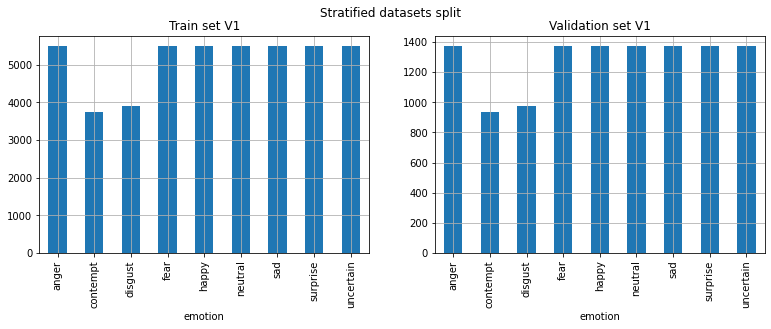

In [ ]:
plt.figure(figsize=(13,4))
plt.suptitle('Stratified datasets split')
plt.subplot(1, 2, 1)
df_train_v1.groupby('emotion')['image_path'].count().plot.bar()
plt.grid()
plt.title('Train set V1')
plt.subplot(1, 2, 2)
df_test_v1.groupby('emotion')['image_path'].count().plot.bar()
plt.title('Validation set V1')
plt.grid()
plt.show()

Заметно как количество изображений по категориям эмоций увеличилось и стало намного сбалансированнее.

In [ ]:
vggface_model = VGGFace(model='resnet50', include_top=False, input_shape=(224, 224, 3))

model_emotion = tf.keras.Sequential([vggface_model, 
                                     tf.keras.layers.Flatten(), 
                                     tf.keras.layers.Dense(9, activation='softmax')])
model_emotion.build(input_shape=(None, 224, 224, 3))

94707712/94694792 [==============================] - 2s 0us/step


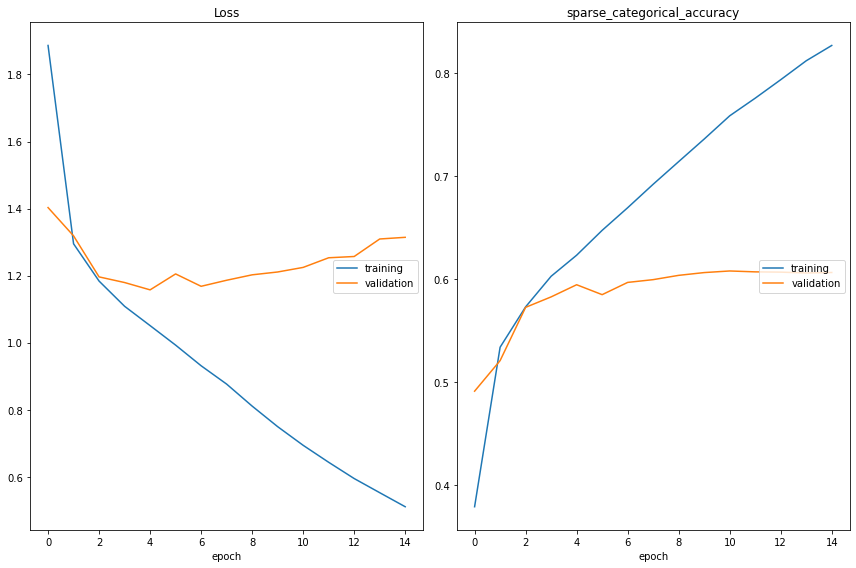

Loss
	training         	 (min:    0.511, max:    1.886, cur:    0.511)
	validation       	 (min:    1.158, max:    1.403, cur:    1.314)
sparse_categorical_accuracy
	training         	 (min:    0.379, max:    0.827, cur:    0.827)
	validation       	 (min:    0.491, max:    0.608, cur:    0.606)

Epoch 00015: val_sparse_categorical_accuracy did not improve from 0.60759


/usr/local/lib/python3.7/dist-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


INFO:tensorflow:Assets written to: /content/drive/MyDrive/Skillbox/CNN_Final_Project/model_emotion/checkpoint_best_vgg_exp/assets
91/91 [==============================] - 154s 2s/step - loss: 1.2241 - sparse_categorical_accuracy: 0.6072


100%|██████████| 5000/5000 [05:22<00:00, 15.50it/s]


In [ ]:
cpt_path = str(PATH_MYDRIVE / 'model_emotion/checkpoint_best_vgg_exp_weights.hdf5')
train_data_gen, val_data_gen, labels_dict = load_dataset(n=1, batch_size=128, image_size=224)

#LearningRateScheduler
def scheduler(epoch, lr):
   if epoch < 8:
     return lr
   else:
     return lr * tf.math.exp(-0.1)

my_callbacks = [PlotLossesCallback(),
                tf.keras.callbacks.ModelCheckpoint(cpt_path,
                                                   monitor='val_sparse_categorical_accuracy',
                                                   verbose=1,
                                                   save_best_only=True,
                                                   save_weights_only=True,
                                                   save_freq='epoch',
                                                   mode='max'),
                tf.keras.callbacks.LearningRateScheduler(scheduler)]  

model_emotion.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

EPOCHS = 15
history = model_emotion.fit(
    train_data_gen,
    epochs=EPOCHS,
    validation_data=val_data_gen,
    callbacks=my_callbacks)


model_emotion.save(PATH_MYDRIVE / 'model_emotion/checkpoint_best_vgg_exp')

model_emotion.load_weights(PATH_MYDRIVE / 'model_emotion/checkpoint_best_vgg_exp_weights.hdf5')
loss, acc = model_emotion.evaluate(val_data_gen)

submission_data = []

for file in tqdm(df_test.image_path):
    img = image.load_img(PATH_TEST / file, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = utils.preprocess_input(x, version=2)
    predicts = model_emotion.predict(x)
    emotion = emotion_mapping[np.argmax(predicts)]
    submission_data.append((file, emotion))
    
sample_submission = pd.DataFrame()
sample_submission['image_path'], sample_submission['emotion'] = zip(*submission_data)

sample_submission.to_csv(PATH_MYDRIVE / 'model_emotion/sample_submission_exp.csv', index=False)

В работе были использованы две предобученные ML-модели (VGGFace и BiT-M r50x1). Применяя различные методы оптимизации, такие как transfer learning, finetuning, augmentation, preprocessing, bounding_box, балансировка датасета, no_multi_face, модели были обучены на оптимизированных датасетах с полными фотографиями и на датасетах с обрезанными по bounding_box лицами. Лучшие результаты получены на аугментированных НЕобрезанных изображениях. Балансировка датасета заведомо "верными" аугментированными копиями исходных фотографий дополнительного улучшения Score на Kaggle не дала. Время инференса сети на Google Colab с десяти-кратным запасом лучше требуемого в ТЗ к диплому.

Также были исследованы предобученные сети Inception_ResNet_V2, Ganeval-cifar10-convnet, Inception_V3, EfficientNet_B7, Mobilenet_v3, применялись разные типы оптимизаторов (напр.RMSProp), варьировались входящие размеры изображений, количество эпох и т.п. Однако, получить более лучшие результаты не представилось возможным (код доп. исследований оставим за рамками работы).

---